<a href="https://colab.research.google.com/github/ShashikanthKungulwar/DL/blob/main/scratch_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

In [30]:
dataset = mnist.load_data()

In [31]:
(x_train,y_train),(x_test,y_test) = dataset

In [32]:
x_train = np.array(x_train,dtype=np.float32)
y_train = np.array(y_train,dtype=np.float32)
x_test = np.array(x_test,dtype=np.float32)
y_test = np.array(y_test,dtype=np.float32)


x_train = x_train/255
x_test = x_test/255

In [33]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [34]:
x_train = x_train.reshape(-1,28*28)
x_test = x_test.reshape(-1,28*28)


In [35]:
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)


In [36]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape


((60000, 784), (60000,), (10000, 784), (10000,))

In [37]:
train_data = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_data = tf.data.Dataset.from_tensor_slices((x_test,y_test))

In [38]:
train_data,test_data

(<_TensorSliceDataset element_spec=(TensorSpec(shape=(784,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>,
 <_TensorSliceDataset element_spec=(TensorSpec(shape=(784,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>)

In [56]:
# mnist dataset parameters
num_classes = 10
num_features = 784

# network parametrs
h1_neurons = 128
h2_neurons = 256

# training parameters
learning_rate = 0.001
batch_size = 256
training_steps = 10000
display_step = 100

In [40]:
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [41]:
random_normal = tf.initializers.RandomNormal()

weights = {
    'h1':tf.Variable(random_normal([num_features,h1_neurons])),
    'h2':tf.Variable(random_normal([h1_neurons,h2_neurons])),
    "out":tf.Variable(random_normal([h2_neurons,num_classes]))
}

bias = {
    'h1':tf.Variable(random_normal([h1_neurons])),
    "h2":tf.Variable(random_normal([h2_neurons])),
    'out':tf.Variable(random_normal([num_classes]))
}

In [42]:
print("weights --------  \n")
print("h1 weights: ", weights["h1"].shape)
print("h2 weights: ", weights["h2"].shape)
print("out weights: ", weights["out"].shape,"\n\n")


print("bias-----\n")
print("h1 bias: ", bias["h1"].shape)
print("h2 bias: ", bias["h2"].shape)
print("out bias: ", bias["out"].shape,"\n\n")

weights --------  

h1 weights:  (784, 128)
h2 weights:  (128, 256)
out weights:  (256, 10) 


bias-----

h1 bias:  (128,)
h2 bias:  (256,)
out bias:  (10,) 




In [43]:
#creating model..

def model(X):
  layer1 = tf.matmul(X,weights["h1"]) + bias["h1"]
  layer1 = tf.nn.relu(layer1)


  layer2 = tf.matmul(layer1,weights["h2"]) + bias["h2"]
  layer2 = tf.nn.relu(layer2)


  out = tf.matmul(layer2,weights["out"]) + bias["out"]
  out = tf.nn.softmax(out)
  return out


In [44]:
#creating model..

def model2(X):
  layer1 = tf.matmul(X,weights["h1"]) + bias["h1"]
  layer1 = tf.nn.relu(layer1)


  layer2 = tf.matmul(layer1,weights["h2"]) + bias["h2"]
  layer2 = tf.nn.relu(layer2)


  out = tf.matmul(layer2,weights["out"]) + bias["out"]
  # out = tf.nn.softmax(out)
  return out


In [45]:
#saininty check
for i in train_data:
  print(model(i[0]).shape)
  print(model(i[0])[1].shape)
  break

(256, 10)
(10,)


In [46]:
#now crossentropy loss  function

def cross_entropy(y_pred,y_test):
  # print(y_pred,y_test)
  y_test = tf.cast(y_test,dtype=tf.int32)
  y_test = tf.one_hot(y_test,depth = num_classes)

  y_pred = tf.clip_by_value(y_pred, 1e-9,1.)

  # print(y_pred.shape,y_test.shape)

  # print(y_pred.shape," ",y_test.shape)
  loss = tf.reduce_mean(-tf.reduce_sum(y_test * tf.math.log(y_pred),axis=-1))

  return loss



#  now accuracy
def accuracy(y_pred,y_test):
  correct_prediction = tf.equal(tf.argmax(y_pred,axis=-1),tf.cast(y_test,dtype=tf.int64))
  return tf.reduce_mean(tf.cast(correct_prediction,dtype=tf.float32))


#optimizer
optimizer = tf.optimizers.SGD(learning_rate)

In [50]:
def run_optim(x,y):

  with tf.GradientTape() as g:
    pred = model(x)
    loss = cross_entropy(pred,y)

  trainable_variables = list(weights.values()) + list(bias.values())

  gradients =  g.gradient(loss,trainable_variables)

  optimizer.apply_gradients(zip(gradients,trainable_variables))

In [57]:
for step,(batch_x,batch_y) in enumerate(train_data.take(training_steps),1):
  run_optim(batch_x,batch_y)

  if step % display_step == 0:
    y_pred = model(batch_x)
    loss = cross_entropy(y_pred,batch_y)
    acc = accuracy(y_pred,batch_y)



    print(f"step {step} loss {loss} acc {acc} ")


step 100 loss 1.2770812511444092 acc 0.7265625 
step 200 loss 1.141819715499878 acc 0.78515625 
step 300 loss 1.1432141065597534 acc 0.73046875 
step 400 loss 1.0638482570648193 acc 0.77734375 
step 500 loss 1.0140925645828247 acc 0.7890625 
step 600 loss 1.0412225723266602 acc 0.83984375 
step 700 loss 0.9424842000007629 acc 0.796875 
step 800 loss 0.9774088859558105 acc 0.81640625 
step 900 loss 0.9642186760902405 acc 0.8203125 
step 1000 loss 1.005292534828186 acc 0.76953125 
step 1100 loss 0.9447274208068848 acc 0.77734375 
step 1200 loss 0.9235976934432983 acc 0.8203125 
step 1300 loss 0.880544900894165 acc 0.796875 
step 1400 loss 0.8483206629753113 acc 0.80078125 
step 1500 loss 0.8880883455276489 acc 0.8125 
step 1600 loss 0.8636712431907654 acc 0.76953125 
step 1700 loss 0.8574934005737305 acc 0.8046875 
step 1800 loss 0.7936703562736511 acc 0.8359375 
step 1900 loss 0.8183935880661011 acc 0.81640625 
step 2000 loss 0.7714080810546875 acc 0.81640625 
step 2100 loss 0.800025939

In [58]:
y_pred = model(x_test)
print(f"acc is :{accuracy(y_pred,y_test)}")

acc is :0.8860999941825867


In [60]:
n_images = 5

test_images = x_test[:n_images]

test_labels = model(test_images)


In [61]:
import matplotlib.pyplot as plt

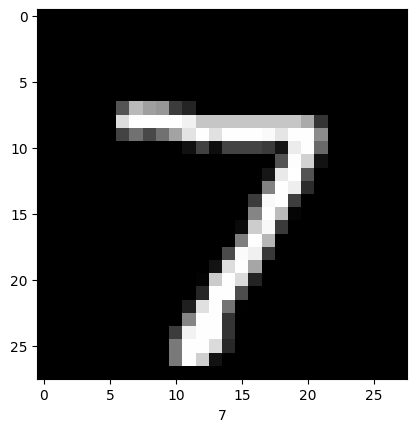

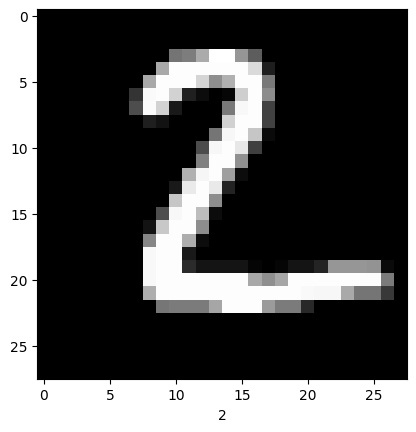

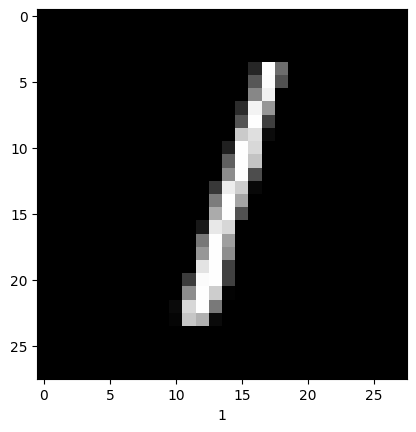

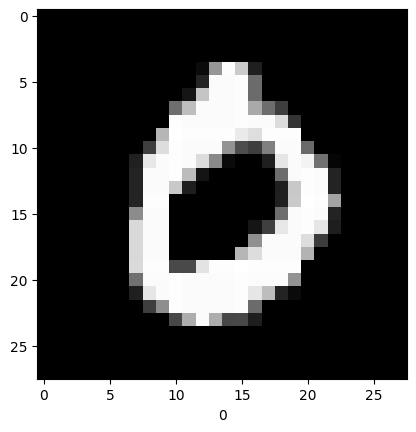

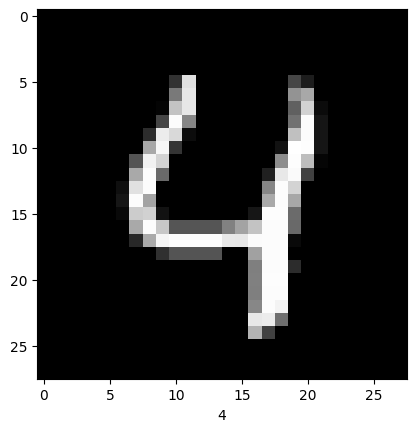

In [68]:
for i in range(n_images):
  plt.imshow(test_images[i].reshape(28,28),cmap ='grey')
  plt.xlabel(np.argmax(test_labels[i]))

  plt.show()

# sainity tests

In [69]:
for i in  train_data:
  print()
  break

In [70]:
for i in train_data:
  print(cross_entropy(model(i[0]),i[1]))
  break

tf.Tensor(0.42050192, shape=(), dtype=float32)


In [71]:
for i in train_data:
  # print(model(i[0]).shape,i[1].shape)
  print(tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=tf.one_hot(tf.cast(i[1],tf.int32),depth = num_classes),logits=model(i[0]))))
  break

tf.Tensor(1.6606076, shape=(), dtype=float32)


In [72]:
# loss function is working good so how
for batch in train_data:
  y_pred = model(batch[0])
  y_pred2 = model2(batch[0])
  print(cross_entropy(y_pred,batch[1]))
  print(tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_pred2,labels=tf.one_hot(tf.cast(batch[1],tf.int32),depth = num_classes))))


#   print(
#     tf.reduce_mean(
#         tf.cast(
#             tf.equal(
#                 tf.argmax(y_pred, axis=-1),
#                 tf.cast(batch[1], tf.int64)
#             ),
#             tf.float32
#         )
#     )
# )
  print(accuracy(y_pred,batch[1]))
  break


tf.Tensor(0.57105815, shape=(), dtype=float32)
tf.Tensor(0.57105815, shape=(), dtype=float32)
tf.Tensor(0.8359375, shape=(), dtype=float32)
